In [1]:
import os  # noqa: I001

n_cores = 32
# XLA reads this flag at import time, so configure virtual CPU devices before importing JAX.
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={n_cores}"
import jax  # noqa: I001, E402

assert jax.local_device_count() == n_cores, "Set JAX CPU count unsuccessful"

In [2]:
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.tree as jt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
from jaxtyping import Array, Float, Key, Scalar, ScalarLike
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm, trange

from src.descent import (
    DescentOutput,
    anchored_extragradient,
    anchored_optimistic_gradient,
    extragradient,
    optimistic_gradient,
)
from src.distribution import Mixture, ParetoDistribution, PointMass
from src.experiment_util import (
    generate_matrix_svd,
    generate_vector_radius,
)
from src.sequence import VDCSchedule
from src.stepsize import ConstantSchedule, EGScheduleFrom, IIDSchedule
from src.types import BiaffineGame, Vmapped
from src.utils import C, tree_unstack, typed

sns.set_theme(
    "paper",
    "ticks",
    font_scale=1.2,
    rc={
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "text.color": "#000000",
        "axes.labelcolor": "#000000",
        "xtick.color": "#000000",
        "ytick.color": "#000000",
    },
)
sns.set_palette("muted")

SAVE_PATH = Path("results")
SAVE_PATH.mkdir(exist_ok=True)

In [3]:
@typed
def generate_game_scale(
    n: int,
    m: int,
    s_min: Float[ScalarLike, ""],
    s_max: Float[ScalarLike, ""],
    radius: Float[ScalarLike, ""],
    key: Key[Scalar, ""],
) -> BiaffineGame:
    """
    Generate a random biaffine game with NE exactly `radius` away from the origin,
    and with singular values in the range ``[s_min, s_max]``.

    Parameters
    ----------
    n, m
        Strategy dimensions for the two players.
    s_min, s_max
        Singular-value range for the bilinear payoff matrix.
    radius
        Radius parameter for each Nash component under this notebook's original convention.
    key
        JAX random key.

    Returns
    -------
    BiaffineGame
        Zero-sum game whose prescribed Nash profile is stationary.
    """
    A_key, r_key, x_key, y_key, c_key = jr.split(key, 5)
    s_min = C(s_min)
    s_max = C(s_max)
    total_radius = C(radius) ** 2
    x_radius = jr.uniform(r_key) * total_radius
    y_radius = total_radius - x_radius
    x_radius = jnp.sqrt(x_radius)
    y_radius = jnp.sqrt(y_radius)
    A = generate_matrix_svd(A_key, n, m, s_min, s_max)
    x_nash = generate_vector_radius(x_key, n, x_radius)
    y_nash = generate_vector_radius(y_key, m, y_radius)
    c = jr.normal(c_key)
    return BiaffineGame.from_Nash(A, x_nash, y_nash, c)

## Experiment 1: Comparison of Power-Law EG vs. regular EG and EAG

In [4]:
n_iter = 2000000
n_games = 128
n_trials = n_cores
n, m = 4, 4
exp_key = jr.key(2026)
min_sigma = 0.01 / n_iter
max_sigma = 1.0  # Also: Lipschitz constant
ne_distance = 1.0
init_point = (jnp.zeros(n), jnp.zeros(m))

games_key, run_key, _, _ = jr.split(exp_key, 4)

games = jax.vmap(
    lambda key: generate_game_scale(
        n, m, min_sigma, max_sigma, ne_distance, key
    )
)(jr.split(games_key, n_games))

In [5]:
base_stepsize = jnp.sqrt(0.5) / max_sigma
sseg_beta = 1 / 0.66
sseg_mixture_p = (2 - sseg_beta) / (2 + sseg_beta)
sseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, sseg_beta)),
    weights=(1 - sseg_mixture_p, sseg_mixture_p),
)
dseg_beta = 1 / 0.99
dseg_mixture_p = 11 * (2 - dseg_beta) / (
    11 * (2 - dseg_beta) + 24 * jnp.log(2) * dseg_beta
)
dseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, dseg_beta)),
    weights=(1 - dseg_mixture_p, dseg_mixture_p),
)
dseg_theta = 2/3 * jnp.pi + 1/3 * jnp.pi / dseg_beta
dseg_rho = 2 + 2 * jnp.cos(dseg_theta)
setups = {
    "Fixed stepsize EG": (
        extragradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
    # "Random Power-Law EG": (extragradient, EGScheduleFrom(IIDSchedule(sseg_distribution))),
    "Single-stepsize power-law EG": (
        extragradient,
        EGScheduleFrom(VDCSchedule(sseg_distribution)),
    ),
    "EAG": (
        anchored_extragradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
    "Double-stepsize power-law EG": (
        extragradient,
        EGScheduleFrom(VDCSchedule(dseg_distribution), ratio=dseg_rho),
    ),
}
results: dict[str, Vmapped[DescentOutput, " n_games"]] = {}

games_layered = jt.map(lambda x: x.reshape(n_cores, x.shape[0] // n_cores, *x.shape[1:]), games)

for name, (algorithm, stepsize_schedule) in setups.items():
    print(f"Running {name}...")

    def run_game(game, key):
        """Run one algorithm on one sampled game."""
        result = algorithm(
            game,
            init_params=init_point,
            schedule=stepsize_schedule,
            n_iter=n_iter,
            key=key,
        )
        return result

    def test_key_inner(games_inner, run_key_):
        """Batch vectorization"""
        run_keys = jr.split(run_key_, n_games // n_cores)
        return jax.vmap(run_game)(games_inner, run_keys)
    
    def test_key_outer(games_outer, run_key_):
        """Batch parallelization, outer loop"""
        run_keys = jr.split(run_key_, n_cores)
        return jax.pmap(test_key_inner)(games_outer, run_keys)

    results[name] = test_key_outer(games_layered, run_key)
    results[name] = jt.map(lambda x: x.reshape(-1, *x.shape[2:]), results[name])

Running Fixed stepsize EG...
Running Single-stepsize power-law EG...
Running EAG...
Running Double-stepsize power-law EG...


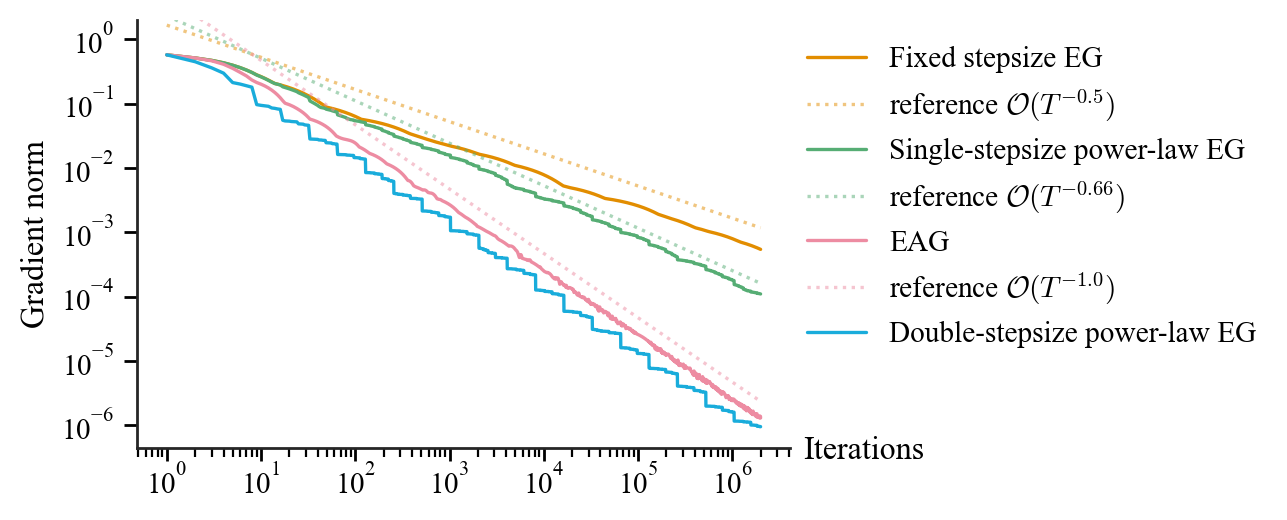

In [6]:
fig, ax = plt.subplots(
    figsize=(7.8 / 1.25, 3 / 1.25), dpi=200, layout="constrained"
)
# Geometric subsampling keeps the figure small while preserving log-scale trends.
ns = jnp.unique(jnp.geomspace(1, n_iter, 4096).round().astype(int))
reference_exponents = {
    "Fixed stepsize EG": -0.5,
    "Single-stepsize power-law EG": -0.66,
    "EAG": -1.0,
}
colors = {
    "Fixed stepsize EG": "#e28d00",
    "Single-stepsize power-law EG": "#56ad74",
    "EAG": "#ed8ca2",
    "Double-stepsize power-law EG": "#19acdb",
}

for name, result in results.items():
    to_plot = result.gradient_norm
    if "Random" in name:
        # Heavy-tailed random runs are averaged geometrically across trials.
        to_plot = jnp.exp(jnp.mean(jnp.log(to_plot), axis=1))
    max_gradient_norm = to_plot.max(axis=0)
    (line,) = ax.plot(ns, max_gradient_norm[ns - 1], label=name, color=colors.get(name))
    if name in reference_exponents:
        coef = reference_exponents[name]
        ax.plot(
            ns,
            (ns / 8) ** coef / 1.7,
            label=f"reference $\\mathcal{{O}}(T^{{{coef}}})$",
            linestyle=":",
            alpha=0.5,
            color=line.get_color(),
        )

sns.despine()

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations", loc="right", labelpad=-23)
ax.xaxis.label.update({"x": 1.205})
ax.xaxis.set_tick_params(pad=1)
ax.set_ylabel("Gradient norm")
ax.legend(loc="upper left", bbox_to_anchor=(0.985, 1), frameon=False)
ax.yaxis.minorticks_off()
ax.set_ylim(None, 2)
fig.get_layout_engine().set(w_pad=0, h_pad=0, wspace=0, hspace=0)

plt.savefig(
    SAVE_PATH / "gradient_norm_comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)

plt.show()

## Experiment 2: Comparison between derandomized and IID power-law EG

In [7]:
n_iter = 100000
n_games = 128
n_trials_inner = 2
n_trials = n_cores // 2
n_epoches = 32
n, m = 3, 3
exp_key = jr.key(2027)
min_sigma = 0.01 / n_iter
max_sigma = 1.0  # Also: Lipschitz constant
ne_distance = 1.0
init_point = (jnp.zeros(n), jnp.zeros(m))

games_key, run_key, _, _ = jr.split(exp_key, 4)

games = jax.vmap(
    lambda key: generate_game_scale(
        n, m, min_sigma, max_sigma, ne_distance, key
    )
)(jr.split(games_key, n_games))

In [8]:
base_stepsize = jnp.sqrt(0.5) / max_sigma
sseg_beta = 1 / 0.66
sseg_mixture_p = (2 - sseg_beta) / (2 + sseg_beta)
sseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, sseg_beta)),
    weights=(1 - sseg_mixture_p, sseg_mixture_p),
)
dseg_beta = 1 / 0.99
dseg_mixture_p = .2
dseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, dseg_beta)),
    weights=(1 - dseg_mixture_p, dseg_mixture_p),
)
dseg_theta = 2/3 * jnp.pi + 1/3 * jnp.pi / dseg_beta
dseg_rho = 2 + 2 * jnp.cos(dseg_theta)
setups = {
    "Fixed stepsize": (
        extragradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
    "Single-stepsize van der Corput": (
        extragradient,
        EGScheduleFrom(VDCSchedule(sseg_distribution)),
    ),
    "Single-stepsize IID": (
        extragradient,
        EGScheduleFrom(IIDSchedule(sseg_distribution)),
    ),
    "Double-stepsize van der Corput": (
        extragradient,
        EGScheduleFrom(VDCSchedule(dseg_distribution), ratio=dseg_rho),
    ),
    "Double-stepsize IID": (
        extragradient,
        EGScheduleFrom(IIDSchedule(dseg_distribution), ratio=dseg_rho),
    ),
}
results: dict[str, Float[Array, " n_games"]] = {}

for name, (algorithm, stepsize_schedule) in setups.items():
    print(f"Running {name}...")

    def run_game(game, key):
        """Run one algorithm on one sampled game."""
        result = algorithm(
            game,
            init_params=init_point,
            schedule=stepsize_schedule,
            n_iter=n_iter,
            key=key,
        )
        return result.gradient_norm

    def test_key(run_key_):
        """Batch one run over all sampled games."""
        run_keys = jr.split(run_key_, n_games)
        return jax.vmap(run_game)(games, run_keys)

    if "IID" in name:
        for epoch_key in tqdm(jr.split(run_key, n_epoches)):
            def test_key_(run_key_):
                run_keys = jr.split(run_key_, n_trials_inner)
                return jax.vmap(test_key)(run_keys)
            epoch_result = jax.pmap(test_key_)(jr.split(epoch_key, n_trials))
            epoch_result = jnp.log(epoch_result).mean(axis=0).mean(axis=0)
            if name not in results:
                results[name] = epoch_result
            else:
                results[name] = results[name] + epoch_result
        results[name] = jnp.exp(results[name] / n_epoches)
    else:
        results[name] = test_key(run_key)

Running Fixed stepsize...
Running Single-stepsize van der Corput...
Running Single-stepsize IID...


  0%|          | 0/32 [00:00<?, ?it/s]

Running Double-stepsize van der Corput...
Running Double-stepsize IID...


  0%|          | 0/32 [00:00<?, ?it/s]

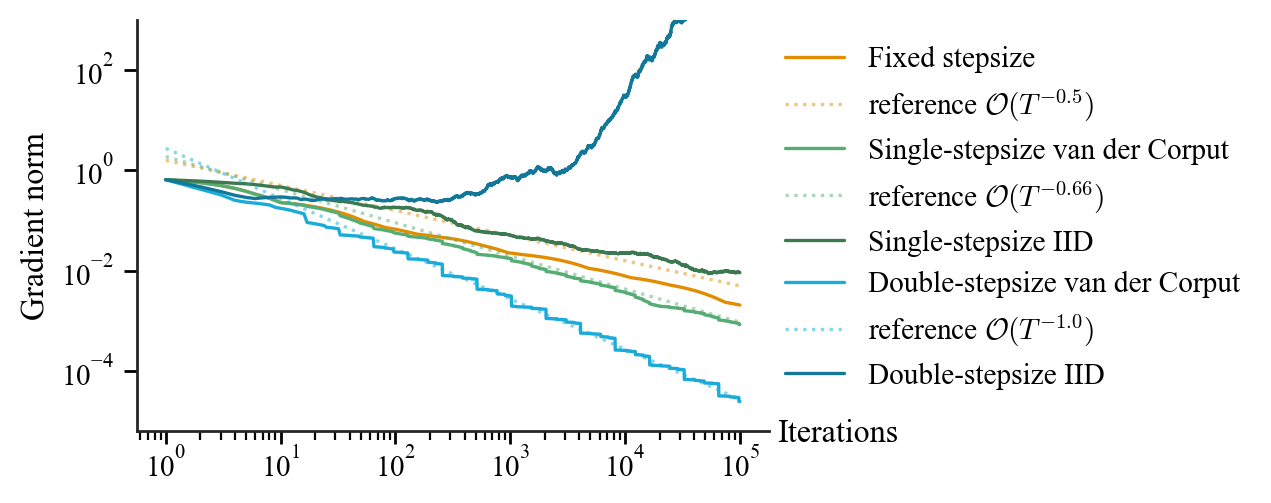

In [9]:
fig, ax = plt.subplots(
    figsize=(7.8 / 1.25, 3 / 1.25), dpi=200, layout="constrained"
)
# Geometric subsampling keeps the figure small while preserving log-scale trends.
ns = jnp.unique(jnp.geomspace(1, n_iter, 4096).round().astype(int))
palette = [(226, 141, 0), (86, 173, 116), (25, 172, 219)]
palette = palette[:3] + [(np.array(x) * 0.7) for x in palette[1:3]]
palette = [palette[0], palette[1], palette[3], palette[2], palette[4]]
palette = [(r / 255, g / 255, b / 255) for r, g, b in palette]
reference_exponents = {
    "Fixed stepsize": -0.5,
    "Single-stepsize van der Corput": -0.66,
    "Double-stepsize van der Corput": -1.0,
}

for name, result in results.items():
    max_gradient_norm = result.max(axis=0)
    (line,) = ax.plot(ns, max_gradient_norm[ns - 1], label=name, color=palette.pop(0))
    if name in reference_exponents:
        coef = reference_exponents[name]
        ax.plot(
            ns,
            (ns / 3) ** coef / 1.1,
            label=f"reference $\\mathcal{{O}}(T^{{{coef}}})$",
            linestyle=":",
            alpha=0.5,
            color=line.get_color(),
        )

sns.despine()

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations", loc="right", labelpad=-23)
ax.xaxis.label.update({"x": 1.205})
ax.xaxis.set_tick_params(pad=1)
ax.set_ylabel("Gradient norm")
ax.legend(loc="upper left", bbox_to_anchor=(0.985, 1), frameon=False)
ax.yaxis.minorticks_off()
ax.set_ylim(None, 1000)
# fig.get_layout_engine().set(w_pad=0, h_pad=0, wspace=0, hspace=0)

plt.savefig(
    SAVE_PATH / "iid_vdc_comparison.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)

plt.show()

## Experiment 3: Experiment 1, but with much larger matrices

In [10]:
n_iter = 100000
n_games = 128
n_trials = n_cores
n, m = 100, 128
exp_key = jr.key(2028)
min_sigma = 0.01 / n_iter
max_sigma = 1.0  # Also: Lipschitz constant
ne_distance = 1.0
init_point = (jnp.zeros(n), jnp.zeros(m))

games_key, run_key, _, _ = jr.split(exp_key, 4)

games = jax.vmap(
    lambda key: generate_game_scale(
        n, m, min_sigma, max_sigma, ne_distance, key
    )
)(jr.split(games_key, n_games))

In [11]:
base_stepsize = jnp.sqrt(0.5) / max_sigma
sseg_beta = 1 / 0.66
sseg_mixture_p = (2 - sseg_beta) / (2 + sseg_beta)
sseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, sseg_beta)),
    weights=(1 - sseg_mixture_p, sseg_mixture_p),
)
dseg_beta = 1 / 0.99
dseg_mixture_p = 11 * (2 - dseg_beta) / (
    11 * (2 - dseg_beta) + 24 * jnp.log(2) * dseg_beta
)
dseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, dseg_beta)),
    weights=(1 - dseg_mixture_p, dseg_mixture_p),
)
dseg_theta = 2/3 * jnp.pi + 1/3 * jnp.pi / dseg_beta
dseg_rho = 2 + 2 * jnp.cos(dseg_theta)
setups = {
    "Fixed stepsize EG": (
        extragradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
    # "Random Power-Law EG": (extragradient, EGScheduleFrom(IIDSchedule(sseg_distribution))),
    "Single-stepsize power-law EG": (
        extragradient,
        EGScheduleFrom(VDCSchedule(sseg_distribution)),
    ),
    "EAG": (
        anchored_extragradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
    "Double-stepsize power-law EG": (
        extragradient,
        EGScheduleFrom(VDCSchedule(dseg_distribution), ratio=dseg_rho),
    ),
}
results: dict[str, Vmapped[DescentOutput, " n_games"]] = {}

games_layered = jt.map(lambda x: x.reshape(n_cores, x.shape[0] // n_cores, *x.shape[1:]), games)

for name, (algorithm, stepsize_schedule) in setups.items():
    print(f"Running {name}...")

    def run_game(game, key):
        """Run one algorithm on one sampled game."""
        result = algorithm(
            game,
            init_params=init_point,
            schedule=stepsize_schedule,
            n_iter=n_iter,
            key=key,
        )
        return result

    def test_key_inner(games_inner, run_key_):
        """Batch vectorization"""
        run_keys = jr.split(run_key_, n_games // n_cores)
        return jax.vmap(run_game)(games_inner, run_keys)
    
    def test_key_outer(games_outer, run_key_):
        """Batch parallelization, outer loop"""
        run_keys = jr.split(run_key_, n_cores)
        return jax.pmap(test_key_inner)(games_outer, run_keys)

    results[name] = test_key_outer(games_layered, run_key)
    results[name] = jt.map(lambda x: x.reshape(-1, *x.shape[2:]), results[name])

Running Fixed stepsize EG...
Running Single-stepsize power-law EG...
Running EAG...
Running Double-stepsize power-law EG...


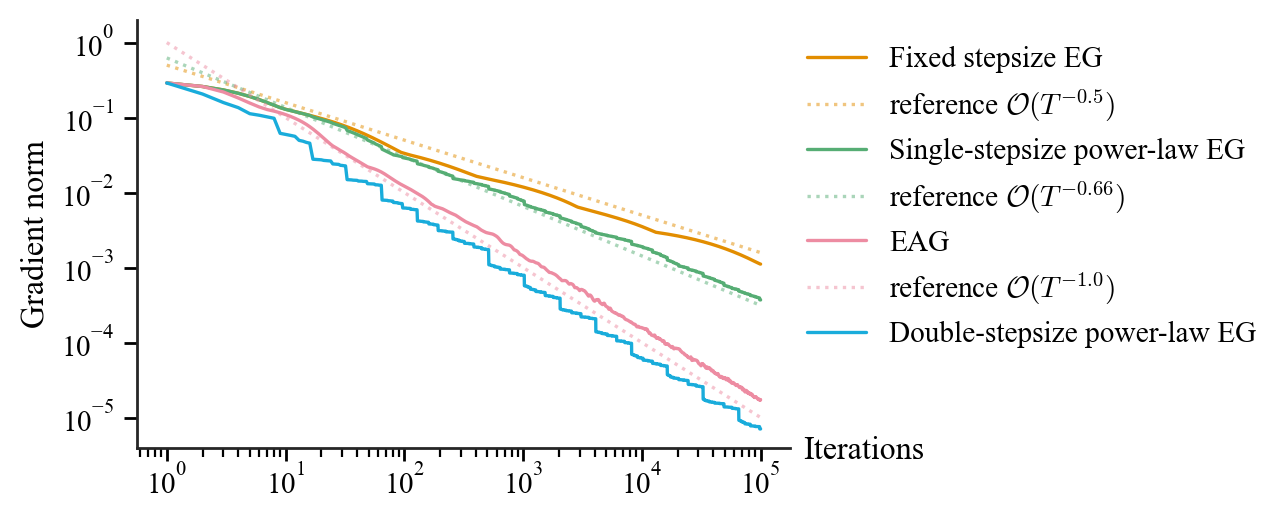

In [12]:
fig, ax = plt.subplots(
    figsize=(7.8 / 1.25, 3 / 1.25), dpi=200, layout="constrained"
)
# Geometric subsampling keeps the figure small while preserving log-scale trends.
ns = jnp.unique(jnp.geomspace(1, n_iter, 4096).round().astype(int))
reference_exponents = {
    "Fixed stepsize EG": -0.5,
    "Single-stepsize power-law EG": -0.66,
    "EAG": -1.0,
}
colors = {
    "Fixed stepsize EG": "#e28d00",
    "Single-stepsize power-law EG": "#56ad74",
    "EAG": "#ed8ca2",
    "Double-stepsize power-law EG": "#19acdb",
}

for name, result in results.items():
    to_plot = result.gradient_norm
    if "Random" in name:
        # Heavy-tailed random runs are averaged geometrically across trials.
        to_plot = jnp.exp(jnp.mean(jnp.log(to_plot), axis=1))
    max_gradient_norm = to_plot.max(axis=0)
    (line,) = ax.plot(ns, max_gradient_norm[ns - 1], label=name, color=colors.get(name))
    if name in reference_exponents:
        coef = reference_exponents[name]
        ax.plot(
            ns,
            (ns / 4) ** coef / 4,
            label=f"reference $\\mathcal{{O}}(T^{{{coef}}})$",
            linestyle=":",
            alpha=0.5,
            color=line.get_color(),
        )

sns.despine()

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations", loc="right", labelpad=-23)
ax.xaxis.label.update({"x": 1.205})
ax.xaxis.set_tick_params(pad=1)
ax.set_ylabel("Gradient norm")
ax.legend(loc="upper left", bbox_to_anchor=(0.985, 1), frameon=False)
ax.yaxis.minorticks_off()
ax.set_ylim(None, 2)
fig.get_layout_engine().set(w_pad=0, h_pad=0, wspace=0, hspace=0)

plt.savefig(
    SAVE_PATH / "gradient_norm_comparison_100.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)

plt.show()

## Experiment 4: Experiment 1, but with OG-family instead of EG

In [13]:
n_iter = 2000000
n_games = 128
n_trials = n_cores
n, m = 4, 4
exp_key = jr.key(2028)
min_sigma = 0.01 / n_iter
max_sigma = 1.0  # Also: Lipschitz constant
ne_distance = 1.0
init_point = (jnp.zeros(n), jnp.zeros(m))

games_key, run_key, _, _ = jr.split(exp_key, 4)

games = jax.vmap(
    lambda key: generate_game_scale(
        n, m, min_sigma, max_sigma, ne_distance, key
    )
)(jr.split(games_key, n_games))

In [14]:
base_stepsize = .5 / max_sigma
sseg_beta = 1 / 0.66
sseg_mixture_p = (2 - sseg_beta) / (2 + sseg_beta)
sseg_distribution = Mixture(
    (PointMass(base_stepsize), ParetoDistribution(base_stepsize, sseg_beta)),
    weights=(1 - sseg_mixture_p, sseg_mixture_p),
)
setups = {
    "Fixed stepsize OG": (
        optimistic_gradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
    "Single-stepsize power-law OG": (
        optimistic_gradient,
        EGScheduleFrom(VDCSchedule(sseg_distribution)),
    ),
    "AOG": (
        anchored_optimistic_gradient,
        EGScheduleFrom(ConstantSchedule(base_stepsize)),
    ),
}
results: dict[str, Vmapped[DescentOutput, " n_games"]] = {}

games_layered = jt.map(lambda x: x.reshape(n_cores, x.shape[0] // n_cores, *x.shape[1:]), games)

for name, (algorithm, stepsize_schedule) in setups.items():
    print(f"Running {name}...")

    def run_game(game, key):
        """Run one algorithm on one sampled game."""
        result = algorithm(
            game,
            init_params=init_point,
            schedule=stepsize_schedule,
            n_iter=n_iter,
            key=key,
        )
        return result

    def test_key_inner(games_inner, run_key_):
        """Batch vectorization"""
        run_keys = jr.split(run_key_, n_games // n_cores)
        return jax.vmap(run_game)(games_inner, run_keys)
    
    def test_key_outer(games_outer, run_key_):
        """Batch parallelization, outer loop"""
        run_keys = jr.split(run_key_, n_cores)
        return jax.pmap(test_key_inner)(games_outer, run_keys)

    results[name] = test_key_outer(games_layered, run_key)
    results[name] = jt.map(lambda x: x.reshape(-1, *x.shape[2:]), results[name])

Running Fixed stepsize OG...
Running Single-stepsize power-law OG...
Running AOG...


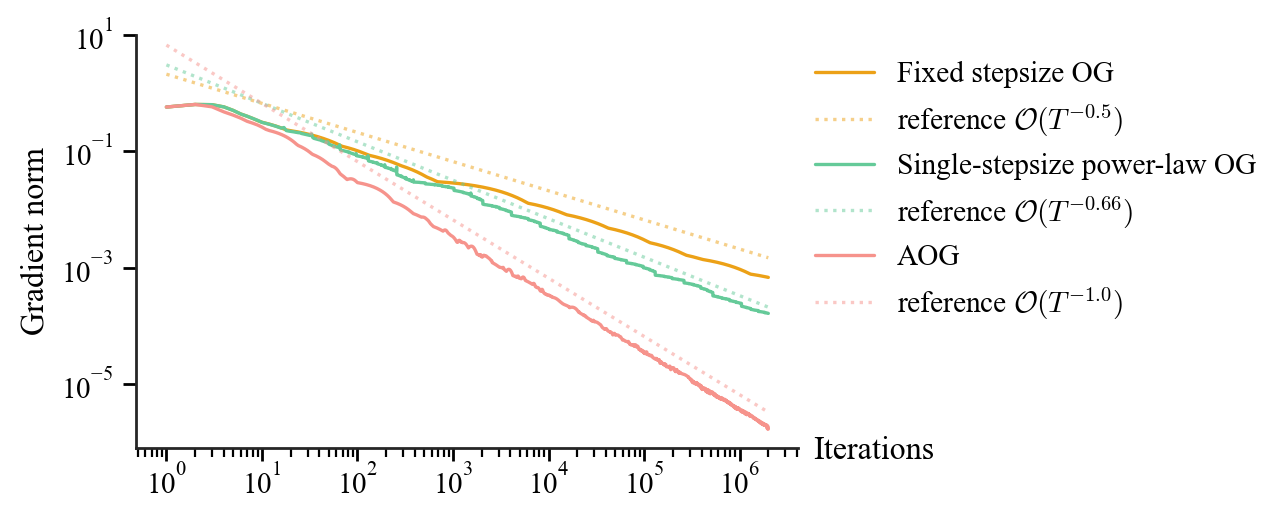

In [15]:
fig, ax = plt.subplots(
    figsize=(7.8 / 1.25, 3 / 1.25), dpi=200, layout="constrained"
)
# Geometric subsampling keeps the figure small while preserving log-scale trends.
ns = jnp.unique(jnp.geomspace(1, n_iter, 4096).round().astype(int))
reference_exponents = {
    "Fixed stepsize OG": -0.5,
    "Single-stepsize power-law OG": -0.66,
    "AOG": -1.0,
}
colors = {
    "Fixed stepsize OG": "#eca117",
    "Single-stepsize power-law OG": "#65ca99",
    "AOG": "#f6938c",
    "Double-stepsize power-law OG": "#19acdb",
}

for name, result in results.items():
    to_plot = result.gradient_norm
    if "Random" in name:
        # Heavy-tailed random runs are averaged geometrically across trials.
        to_plot = jnp.exp(jnp.mean(jnp.log(to_plot), axis=1))
    max_gradient_norm = to_plot.max(axis=0)
    (line,) = ax.plot(ns, max_gradient_norm[ns - 1], label=name, color=colors.get(name))
    if name in reference_exponents:
        coef = reference_exponents[name]
        ax.plot(
            ns,
            (ns / 10) ** coef / 1.5,
            label=f"reference $\\mathcal{{O}}(T^{{{coef}}})$",
            linestyle=":",
            alpha=0.5,
            color=line.get_color(),
        )

sns.despine()

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations", loc="right", labelpad=-23)
ax.xaxis.label.update({"x": 1.205})
ax.xaxis.set_tick_params(pad=1)
ax.set_ylabel("Gradient norm")
ax.legend(loc="upper left", bbox_to_anchor=(0.985, 1), frameon=False)
ax.yaxis.minorticks_off()
ax.set_ylim(None, 10)
fig.get_layout_engine().set(w_pad=0, h_pad=0, wspace=0, hspace=0)

plt.savefig(
    SAVE_PATH / "gradient_norm_comparison_og.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
)

plt.show()